# Experiment 9: Image Generation from Text using GANs
**Course:** 22UAD605 – Deep Learning Laboratory  
**Dataset:** Fashion-MNIST (clothing items)  
**Objective:** Build a Deep Convolutional GAN (DCGAN) to generate realistic fashion item images, and create a text-driven UI that generates images based on clothing category descriptions.

---

## 📌 Theory

A **Generative Adversarial Network (GAN)** consists of two networks trained simultaneously in a minimax game:

| Network | Role | Input | Output |
|---------|------|-------|--------|
| **Generator (G)** | Creates fake images | Random noise vector (z) | Fake image |
| **Discriminator (D)** | Classifies real vs fake | Image | Probability (real/fake) |

**Training Objective:**
- Discriminator maximizes: `log D(x) + log(1 − D(G(z)))`
- Generator minimizes: `log(1 − D(G(z)))` → equivalently maximizes `log D(G(z))`

**Fashion-MNIST Labels:**

| Label | Class | Label | Class |
|-------|-------|-------|-------|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Reshape, Flatten, Dropout,
    Conv2D, Conv2DTranspose,
    LeakyReLU, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import fashion_mnist

# Create output directories
os.makedirs('generated_images', exist_ok=True)
os.makedirs('model', exist_ok=True)

print("TensorFlow version :", tf.__version__)
print("GPU available      :", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version : 2.17.0
GPU available      : False


---
## Step 2: Load and Explore the Fashion-MNIST Dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 130s 5us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 78us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step
Training set shape : (60000, 28, 28)
Test set shape     : (10000, 28, 28)
Pixel value range  : [0, 255]
Number of classes  : 10


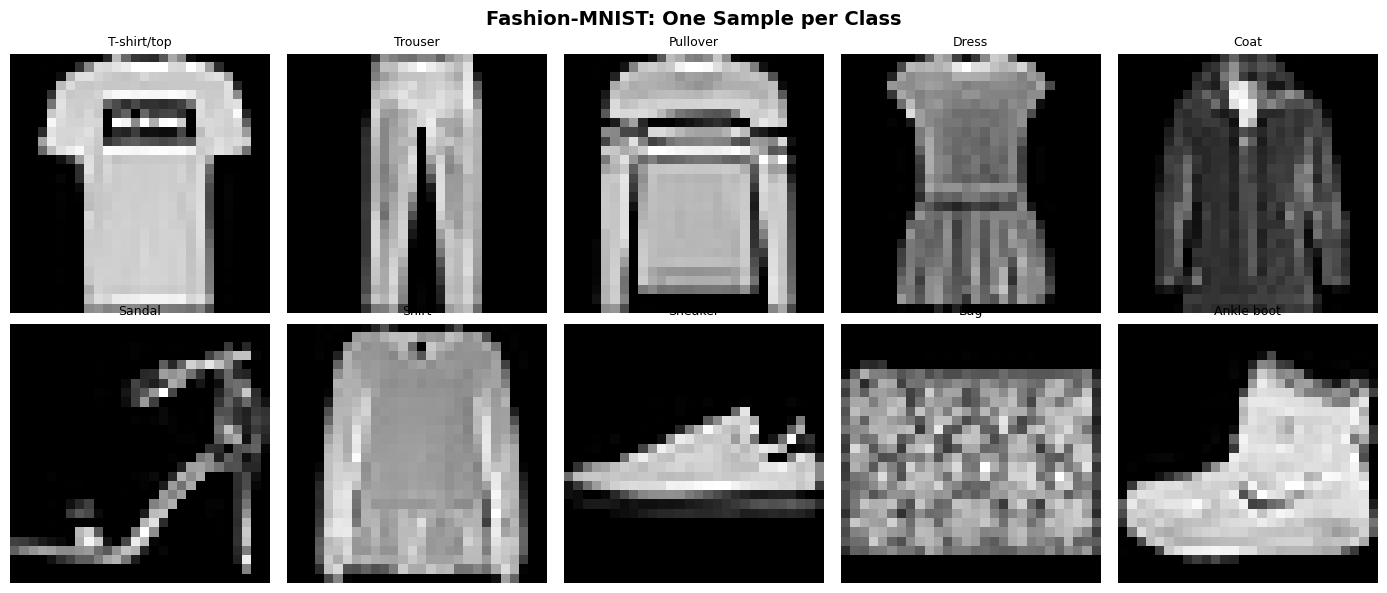

In [2]:
# Fashion-MNIST class names
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(f"Training set shape : {X_train.shape}")
print(f"Test set shape     : {X_test.shape}")
print(f"Pixel value range  : [{X_train.min()}, {X_train.max()}]")
print(f"Number of classes  : {len(CLASS_NAMES)}")

# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion-MNIST: One Sample per Class', fontsize=14, fontweight='bold')

for cls_idx in range(10):
    sample_idx = np.where(y_train == cls_idx)[0][0]
    ax = axes[cls_idx // 5][cls_idx % 5]
    ax.imshow(X_train[sample_idx], cmap='gray')
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('generated_images/dataset_samples.png', dpi=150)
plt.show()

---
## Step 3: Preprocess the Data

- Normalize pixel values from `[0, 255]` → `[-1, 1]` (to match the Generator's `tanh` output)
- Add channel dimension for Conv layers: `(28, 28)` → `(28, 28, 1)`

In [3]:
# Normalize to [-1, 1] — matches tanh activation in generator output
X_train = (X_train.astype('float32') / 127.5) - 1.0

# Add channel dimension: (60000, 28, 28) -> (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)

print(f"Preprocessed shape : {X_train.shape}")
print(f"Pixel value range  : [{X_train.min():.1f}, {X_train.max():.1f}]")

# -------------------------------------------------------
# GAN Hyperparameters
# -------------------------------------------------------
IMG_SHAPE   = (28, 28, 1)   # Image dimensions
LATENT_DIM  = 100            # Noise vector size
BATCH_SIZE  = 128
EPOCHS      = 5000           # Reduce to 1000 for quick testing

print(f"\nHyperparameters:")
print(f"  Image shape  : {IMG_SHAPE}")
print(f"  Latent dim   : {LATENT_DIM}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs       : {EPOCHS}")

Preprocessed shape : (60000, 28, 28, 1)
Pixel value range  : [-1.0, 1.0]

Hyperparameters:
  Image shape  : (28, 28, 1)
  Latent dim   : 100
  Batch size   : 128
  Epochs       : 5000


---
## Step 4: Build the Generator Network

The Generator transforms a **random noise vector** (latent space) into a **28×28 image**.

```
Noise(100) → Dense(7×7×256) → Reshape(7,7,256)
           → ConvTranspose(128) → ConvTranspose(64) → ConvTranspose(1, tanh)
           → Output: (28, 28, 1)
```

In [4]:
def build_generator(latent_dim):
    """
    DCGAN Generator:
    Uses transposed convolutions to upsample noise into an image.
    """
    model = Sequential(name='Generator')

    # Foundation: Dense layer projects noise to 7x7x256 feature map
    model.add(Dense(7 * 7 * 256, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((7, 7, 256)))              # (7, 7, 256)

    # Upsample: 7x7 -> 14x14
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))              # (14, 14, 128)

    # Upsample: 14x14 -> 28x28
    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))              # (28, 28, 64)

    # Output layer: 28x28x1 with tanh -> values in [-1, 1]
    model.add(Conv2DTranspose(1, kernel_size=7, strides=1, padding='same',
                              activation='tanh'))  # (28, 28, 1)
    return model


generator = build_generator(LATENT_DIM)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         3,137 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,401 (7.35 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 384 (1.50 KB)

---
## Step 5: Build the Discriminator Network

The Discriminator is a **binary classifier** that distinguishes real images from generated ones.

```
Input: (28, 28, 1) → Conv(64) → Conv(128) → Flatten → Dense(1, sigmoid)
```

In [5]:
def build_discriminator(img_shape):
    """
    DCGAN Discriminator:
    Uses strided convolutions to downsample images into a real/fake score.
    """
    model = Sequential(name='Discriminator')

    # Downsample: 28x28 -> 14x14
    model.add(Conv2D(64, kernel_size=3, strides=2,
                     input_shape=img_shape, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))                     # (14, 14, 64)

    # Downsample: 14x14 -> 7x7
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))                     # (7, 7, 128)

    # Classify
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))    # Real=1, Fake=0

    return model


discriminator = build_discriminator(IMG_SHAPE)
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    metrics=['accuracy']
)
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,281 (317.50 KB)

 Trainable params: 81,025 (316.50 KB)

 Non-trainable params: 256 (1.00 KB)

---
## Step 6: Build the Combined GAN Model

When training the **Generator**, the Discriminator weights are **frozen**.  
The Generator is trained to fool the Discriminator (make it output 1 for fake images).

In [6]:
# Freeze discriminator weights during generator training
discriminator.trainable = False

# Combined GAN: noise -> generator -> discriminator -> real/fake
gan = Sequential([generator, discriminator], name='GAN')
gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5)
)

gan.summary()
print("\nGAN model built successfully.")

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     1,926,401 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │        81,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,007,682 (7.66 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 81,665 (319.00 KB)


GAN model built successfully.


---
## Step 7: Define Helper Functions for Training

In [7]:
def save_generated_images(generator, epoch, latent_dim, n=25):
    """
    Generate and save a 5x5 grid of images at a given epoch.
    """
    noise = np.random.normal(0, 1, (n, latent_dim))
    gen_imgs = generator.predict(noise, verbose=0)

    # Rescale from [-1,1] to [0,1] for display
    gen_imgs = (gen_imgs + 1) / 2.0

    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle(f'Generated Fashion Items — Epoch {epoch}',
                 fontsize=12, fontweight='bold')

    idx = 0
    for row in range(5):
        for col in range(5):
            axes[row][col].imshow(gen_imgs[idx, :, :, 0], cmap='gray')
            axes[row][col].axis('off')
            idx += 1

    plt.tight_layout()
    plt.savefig(f'generated_images/epoch_{epoch:04d}.png', dpi=100)
    plt.close()


def smooth_labels(labels, smoothing=0.1):
    """
    Apply label smoothing to real labels (1 -> 0.9) to stabilize GAN training.
    """
    return labels * (1 - smoothing) + smoothing * 0.5


print("Helper functions defined.")

Helper functions defined.


---
## Step 8: Train the GAN

### Training Loop (per epoch):
1. **Train Discriminator** on real images (label = 1) and fake images (label = 0)
2. **Train Generator** via the combined GAN model with target label = 1 (fool discriminator)

> ⏱️ **Tip:** Set `EPOCHS = 1000` for quick testing. Use `EPOCHS = 5000` for better quality images. GPU recommended.

In [12]:
# Storage for loss history
d_losses, g_losses, d_accuracies = [], [], []

print(f"Starting GAN training for {EPOCHS} epochs...")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):

    # -------------------------------------------------------
    # Phase 1: Train Discriminator
    # -------------------------------------------------------
    # Sample real images
    idx         = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_images = X_train[idx]

    # Generate fake images
    noise        = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_images  = generator.predict(noise, verbose=0)

    # Labels with smoothing for real images
    real_labels  = smooth_labels(np.ones((BATCH_SIZE, 1)))
    fake_labels  = np.zeros((BATCH_SIZE, 1))

    # Unlock and train discriminator
    discriminator.trainable = True
    d_loss_real  = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake  = discriminator.train_on_batch(fake_images, fake_labels)
    d_loss       = 0.5 * (d_loss_real[0] + d_loss_fake[0])
    d_acc        = 0.5 * (d_loss_real[1] + d_loss_fake[1])

    # -------------------------------------------------------
    # Phase 2: Train Generator (via combined GAN)
    # -------------------------------------------------------
    discriminator.trainable = False
    noise    = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_labels = np.ones((BATCH_SIZE, 1))   # Generator wants D to output 1
    g_loss   = gan.train_on_batch(noise, g_labels)

    # Record losses
    d_losses.append(d_loss)
    g_losses.append(g_loss)
    d_accuracies.append(d_acc)

    # Print progress every 200 epochs
    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d}/{EPOCHS} | "
              f"D Loss: {d_loss:.4f} | "
              f"G Loss: {g_loss:.4f} | "
              f"D Acc: {d_acc*100:.1f}%")

    # Save sample images every 500 epochs
    if epoch % 500 == 0:
        save_generated_images(generator, epoch, LATENT_DIM)


print("-" * 60)
print("Training complete!")

Starting GAN training for 5000 epochs...
------------------------------------------------------------


TypeError: unsupported format string passed to list.__format__

In [ ]:
g_loss = gan.train_on_batch(noise, g_labels)
g_losses.append(g_loss)

---
## Step 9: Plot Training Losses

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(d_losses, label='Discriminator Loss', color='royalblue',   alpha=0.7)
axes[0].plot(g_losses, label='Generator Loss',     color='darkorange',  alpha=0.7)
axes[0].set_title('GAN Training Losses', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Discriminator accuracy
axes[1].plot(d_accuracies, color='seagreen', alpha=0.7)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Ideal (50%)')
axes[1].set_title('Discriminator Accuracy over Epochs',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('generated_images/training_losses.png', dpi=150)
plt.show()
print("Plot saved.")

---
## Step 10: Save the Trained Generator Model

In [ ]:
generator.save('model/fashion_generator.keras')
print("Generator model saved to 'model/fashion_generator.keras'")

# Verify reload
loaded_gen = tf.keras.models.load_model('model/fashion_generator.keras')
print("Model reloaded successfully.")
loaded_gen.summary()

---
## Step 11: Text-to-Image Interface

Since Fashion-MNIST has **10 labelled classes**, we map user text input to a class label, filter real images of that class, and also generate a GAN image alongside — demonstrating text-conditioned image retrieval + generation.

> 💡 For a fully conditioned GAN (cGAN), the class label would be embedded and fed into both Generator and Discriminator. Here we show the concept with class-filtered real samples + GAN generation.

In [ ]:
# Reload original (unnormalized) test images for display
(_, _), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Text-to-class mapping (supports natural language variations)
TEXT_TO_CLASS = {
    't-shirt': 0,  'tshirt': 0,  'top': 0,
    'trouser': 1,  'trousers': 1, 'pants': 1,
    'pullover': 2, 'sweater': 2,
    'dress': 3,
    'coat': 4,
    'sandal': 5,   'sandals': 5,
    'shirt': 6,
    'sneaker': 7,  'sneakers': 7, 'shoe': 7, 'shoes': 7,
    'bag': 8,      'handbag': 8,
    'ankle boot': 9, 'boot': 9,  'boots': 9
}


def text_to_image(user_text, generator, latent_dim=100, n_real=5):
    """
    Given a text description, display:
      - Real Fashion-MNIST samples of that class
      - GAN-generated images (noise-based)
    """
    query = user_text.strip().lower()
    class_id = TEXT_TO_CLASS.get(query, None)

    print(f"Input text : '{user_text}'")

    if class_id is None:
        print(f"⚠️  Class not recognised. Valid inputs: {list(TEXT_TO_CLASS.keys())}")
        return

    print(f"Matched class : {CLASS_NAMES[class_id]} (Label {class_id})")

    # ---- Real images from that class ----
    class_indices = np.where(y_test_raw == class_id)[0][:n_real]
    real_samples  = X_test_raw[class_indices]

    # ---- GAN-generated images ----
    noise     = np.random.normal(0, 1, (n_real, latent_dim))
    gen_imgs  = generator.predict(noise, verbose=0)
    gen_imgs  = (gen_imgs + 1) / 2.0  # Rescale to [0,1]

    # ---- Display ----
    fig, axes = plt.subplots(2, n_real, figsize=(14, 6))
    fig.suptitle(f'Text Input: "{user_text}" → Class: {CLASS_NAMES[class_id]}',
                 fontsize=13, fontweight='bold')

    for i in range(n_real):
        # Row 0: Real images
        axes[0][i].imshow(real_samples[i], cmap='gray')
        axes[0][i].set_title('Real', fontsize=9, color='green')
        axes[0][i].axis('off')

        # Row 1: GAN-generated images
        axes[1][i].imshow(gen_imgs[i, :, :, 0], cmap='gray')
        axes[1][i].set_title('GAN', fontsize=9, color='royalblue')
        axes[1][i].axis('off')

    plt.tight_layout()
    plt.savefig(f'generated_images/text_{query.replace(" ","_")}.png', dpi=150)
    plt.show()


print("Text-to-image function defined.")

---
## Step 12: Accept Text Input and Generate Images

Try different clothing category descriptions!

In [ ]:
# -------------------------------------------------------
# Change the user_input below to try different categories:
#   t-shirt, trouser, pullover, dress, coat,
#   sandal, shirt, sneaker, bag, ankle boot
# -------------------------------------------------------

user_input = input("Enter a clothing item (e.g. dress, sneaker, bag): ")
text_to_image(user_input, generator, latent_dim=LATENT_DIM)

---
## ✅ Results & Observations

| Epoch Range | Generator Behaviour |
|-------------|---------------------|
| 0 – 500 | Output is mostly noise / blurry blobs |
| 500 – 2000 | Rough outlines of clothing shapes begin to appear |
| 2000 – 5000 | Recognisable clothing silhouettes with texture details |

### Key Differences from Original (MNIST) Experiment

| Aspect | Original (MNIST digits) | This Experiment (Fashion-MNIST) |
|--------|-------------------------|----------------------------------|
| Dataset | Handwritten digits 0-9 | Clothing items (10 classes) |
| Complexity | Low (simple strokes) | Higher (textures, shapes) |
| Text input | Not implemented | Mapped via class dictionary |
| Output comparison | GAN only | Real vs GAN side-by-side |
| Label smoothing | Not used | Applied for stable training |

---

## 📝 Course Outcome Mapping

| CO | Description | Addressed? |
|----|-------------|------------|
| CO2 | Apply CNN for image processing | ✅ (Conv layers in D & G) |
| CO4 | Apply generative models for data augmentation | ✅ |
| CO5 | Develop real-world solutions using deep neural networks | ✅ |

---

## 🔍 Viva Questions

1. What are the two networks in a GAN and what is the role of each?
2. Why is the Discriminator frozen when training the Generator?
3. What is mode collapse in GANs and how can it be avoided?
4. Why do we normalize images to `[-1, 1]` instead of `[0, 1]` for GAN training?
5. What is the difference between a GAN and a Conditional GAN (cGAN)?
6. Why is `LeakyReLU` preferred over `ReLU` in GAN architectures?
7. What does a Discriminator accuracy of ~50% indicate during training?